# step1 : import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import f1_score,recall_score
from sklearn.model_selection import GridSearchCV

# step2: Load Dataset

In [3]:
df = pd.read_csv("AI-Based Hiring Prediction System (1).csv")
print(df["Recruiter Decision"].unique())

['Hire' 'Reject']


In [ ]:
df

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100
...,...,...,...,...,...,...,...,...,...,...,...
995,996,Brenda Williams,"Cybersecurity, Linux, Ethical Hacking",0,B.Sc,NaN,Cybersecurity Analyst,Reject,114364,9,60
996,997,Colleen Hicks,"Deep Learning, Machine Learning",0,MBA,Deep Learning Specialization,Data Scientist,Reject,103294,5,45
997,998,Michelle Molina,"TensorFlow, NLP",0,B.Tech,Google ML,AI Researcher,Hire,113855,9,65
998,999,Danielle Horn,"Linux, Networking, Cybersecurity, Ethical Hacking",8,PhD,AWS Certified,Cybersecurity Analyst,Hire,83146,10,100


# Step 3: Basic Data Analysis

In [ ]:
print(df.head)

<bound method NDFrame.head of      Resume_ID              Name  \
0            1        Ashley Ali   
1            2      Wesley Roman   
2            3     Corey Sanchez   
3            4  Elizabeth Carney   
4            5        Julie Hill   
..         ...               ...   
995        996   Brenda Williams   
996        997     Colleen Hicks   
997        998   Michelle Molina   
998        999     Danielle Horn   
999       1000      Chad Collins   

                                                Skills  Experience (Years)  \
0                             TensorFlow, NLP, Pytorch                  10   
1         Deep Learning, Machine Learning, Python, SQL                  10   
2                Ethical Hacking, Cybersecurity, Linux                   1   
3                          Python, Pytorch, TensorFlow                   7   
4                                     SQL, React, Java                   4   
..                                                 ...               

In [ ]:
print(df.info)

<bound method DataFrame.info of      Resume_ID              Name  \
0            1        Ashley Ali   
1            2      Wesley Roman   
2            3     Corey Sanchez   
3            4  Elizabeth Carney   
4            5        Julie Hill   
..         ...               ...   
995        996   Brenda Williams   
996        997     Colleen Hicks   
997        998   Michelle Molina   
998        999     Danielle Horn   
999       1000      Chad Collins   

                                                Skills  Experience (Years)  \
0                             TensorFlow, NLP, Pytorch                  10   
1         Deep Learning, Machine Learning, Python, SQL                  10   
2                Ethical Hacking, Cybersecurity, Linux                   1   
3                          Python, Pytorch, TensorFlow                   7   
4                                     SQL, React, Java                   4   
..                                                 ...             

In [ ]:
print(df.describe)

<bound method NDFrame.describe of      Resume_ID              Name  \
0            1        Ashley Ali   
1            2      Wesley Roman   
2            3     Corey Sanchez   
3            4  Elizabeth Carney   
4            5        Julie Hill   
..         ...               ...   
995        996   Brenda Williams   
996        997     Colleen Hicks   
997        998   Michelle Molina   
998        999     Danielle Horn   
999       1000      Chad Collins   

                                                Skills  Experience (Years)  \
0                             TensorFlow, NLP, Pytorch                  10   
1         Deep Learning, Machine Learning, Python, SQL                  10   
2                Ethical Hacking, Cybersecurity, Linux                   1   
3                          Python, Pytorch, TensorFlow                   7   
4                                     SQL, React, Java                   4   
..                                                 ...           

In [ ]:
print(df.shape)

(1000, 11)


In [ ]:
print(df.columns)

Index(['Resume_ID', 'Name', 'Skills', 'Experience (Years)', 'Education',
       'Certifications', 'Job Role', 'Recruiter Decision',
       'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)'],
      dtype='object')


# STEP 4: Missing Value

In [ ]:
print(df.isnull().sum())

Resume_ID                   0
Name                        0
Skills                      0
Experience (Years)          0
Education                   0
Certifications            274
Job Role                    0
Recruiter Decision          0
Salary Expectation ($)      0
Projects Count              0
AI Score (0-100)            0
dtype: int64


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
print('Unique values for Education:', df['Education'].unique())

Unique values for Education: ['B.Sc' 'MBA' 'B.Tech' 'PhD' 'M.Tech']


In [ ]:
print(df.select_dtypes(include=np.number).corr())

                        Resume_ID  Experience (Years)  Salary Expectation ($)  \
Resume_ID                1.000000            0.021094                0.001090   
Experience (Years)       0.021094            1.000000                0.034814   
Salary Expectation ($)   0.001090            0.034814                1.000000   
Projects Count           0.024475           -0.066596                0.021759   
AI Score (0-100)         0.029713            0.777042                0.033354   

                        Projects Count  AI Score (0-100)  
Resume_ID                     0.024475          0.029713  
Experience (Years)           -0.066596          0.777042  
Salary Expectation ($)        0.021759          0.033354  
Projects Count                1.000000          0.358666  
AI Score (0-100)              0.358666          1.000000  


In [4]:
en = LabelEncoder()
df['Education'] = en.fit_transform(df['Education'])
df['Recruiter Decision'] = en.fit_transform(df['Recruiter Decision'])
print(en.classes_)


['Hire' 'Reject']


In [5]:
en = LabelEncoder()
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = en.fit_transform(df[col])


In [ ]:
print(df.corr())

                        Resume_ID      Name    Skills  Experience (Years)  \
Resume_ID                1.000000 -0.058370  0.009690            0.021094   
Name                    -0.058370  1.000000  0.027029            0.039774   
Skills                   0.009690  0.027029  1.000000            0.019443   
Experience (Years)       0.021094  0.039774  0.019443            1.000000   
Education                0.058655 -0.040471 -0.076315           -0.034958   
Certifications           0.002661 -0.007711 -0.048691            0.028291   
Job Role                 0.017516  0.021039 -0.183265            0.022402   
Recruiter Decision      -0.034135 -0.012907 -0.050019           -0.576235   
Salary Expectation ($)   0.001090  0.020632  0.006505            0.034814   
Projects Count           0.024475 -0.007041  0.026953           -0.066596   
AI Score (0-100)         0.029713  0.021844  0.045978            0.777042   

                        Education  Certifications  Job Role  \
Resume_ID   

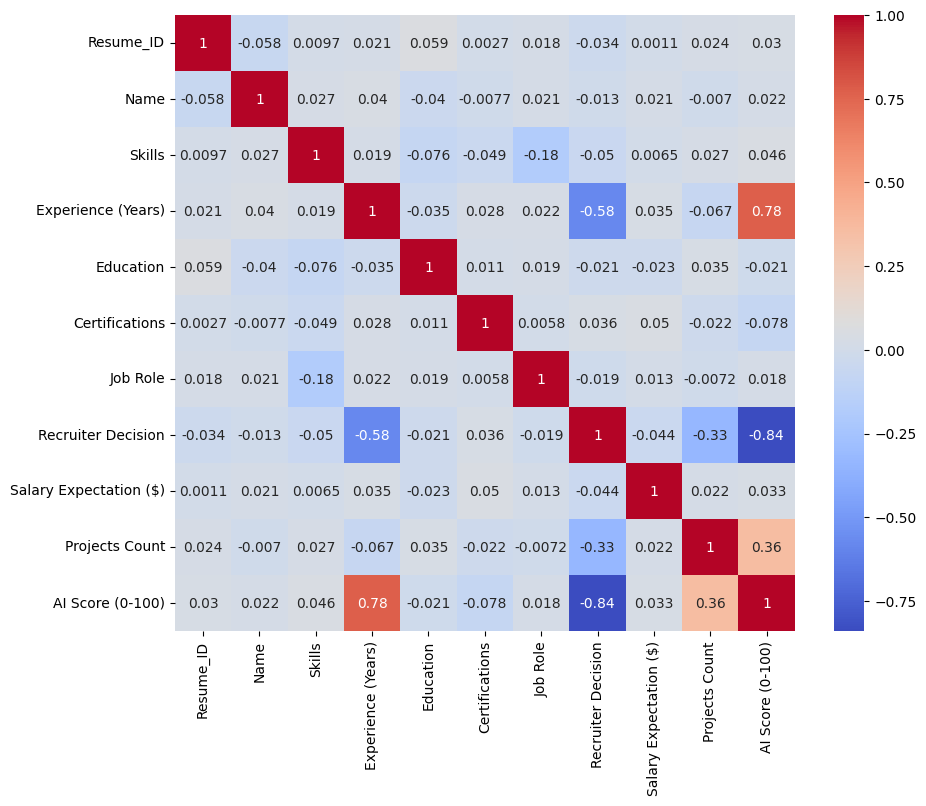

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

# Step 8: Analyze Target Variable

In [ ]:
print(df["Recruiter Decision"].unique())

[0 1]


In [ ]:
print(df["Recruiter Decision"].value_counts())

Recruiter Decision
0    812
1    188
Name: count, dtype: int64


In [ ]:
df.drop(["Resume_ID", "Name"], axis=1, inplace=True)

In [ ]:
x = df.drop("Recruiter Decision", axis=1)
y = df["Recruiter Decision"]

test_train

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y,random_state=42,test_size=0.2
)
print(x_train.head)

<bound method NDFrame.head of      Skills  Experience (Years)  Education  Certifications  Job Role  \
29      213                  10          1               0         2   
535     188                   4          4               3         3   
695      22                   3          3               1         1   
557      91                   7          1               1         2   
836      35                   9          1               2         2   
..      ...                 ...        ...             ...       ...   
106     107                   9          1               0         0   
270     102                   0          4               2         2   
860     169                   8          1               0         0   
435     137                   7          2               1         2   
102      55                   2          3               1         1   

     Salary Expectation ($)  Projects Count  AI Score (0-100)  
29                    59926              

In [ ]:
scalar = StandardScaler()
x_train_scalar = scalar.fit_transform(x_train)
x_test_scalar = scalar.transform(x_test)


In [ ]:
log = LogisticRegression()
log.fit(x_train_scalar,y_train)
y_pred = log.predict(x_test_scalar)

In [ ]:
print("Accuracy",accuracy_score(y_test,y_pred))
print("Confusion Matrix",confusion_matrix(y_test,y_pred))
print("Classification Report",classification_report(y_test,y_pred))
print("F1",f1_score(y_test,y_pred))
print("Recall",recall_score(y_test,y_pred))

Accuracy 1.0
Confusion Matrix [[154   0]
 [  0  46]]
Classification Report               precision    recall  f1-score   support

           0       1.00      1.00      1.00       154
           1       1.00      1.00      1.00        46

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

F1 1.0
Recall 1.0


In [ ]:
models = {

    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier()
}
result = []


In [ ]:
for name, model in models.items():

    model.fit(x_train_scalar, y_train)

    y_pred = model.predict(x_test_scalar)

    accuracy = accuracy_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    result.append([
        name,
        accuracy,
        recall,
        f1
    ])

In [ ]:
results_df = pd.DataFrame(
    result,
    columns=[
        "Model",
        "Accuracy",
        "Recall",
        "F1 Score"
    ]
)

print(results_df)

                 Model  Accuracy  Recall  F1 Score
0        Decision Tree       1.0     1.0       1.0
1  Logistic Regression       1.0     1.0       1.0
2        Random Forest       1.0     1.0       1.0


# Step 15: Select Best Model

In [ ]:
best_model_name = results_df.loc[
    results_df["Accuracy"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Decision Tree


# Step 16: Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [5, 10, 15, None],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

# Step 17 TUNED MODEL EVALUATION

In [ ]:
best_model = grid.best_estimator_

best_pred = best_model.predict(x_test_scalar)

print("\nTUNED RANDOM FOREST")

print("Accuracy :", accuracy_score(y_test, best_pred))
print("Recall   :", recall_score(y_test, best_pred))
print("F1 Score :", f1_score(y_test, best_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, best_pred))

print("\nClassification Report")
print(classification_report(y_test, best_pred))


TUNED RANDOM FOREST
Accuracy : 0.23
Recall   : 1.0
F1 Score : 0.37398373983739835

Confusion Matrix
[[  0 154]
 [  0  46]]

Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       154
           1       0.23      1.00      0.37        46

    accuracy                           0.23       200
   macro avg       0.12      0.50      0.19       200
weighted avg       0.05      0.23      0.09       200



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no

FEATURE IMPORTANCE

In [ ]:
importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance")
print(importance)



Feature Importance
                  Feature  Importance
7        AI Score (0-100)    0.667009
1      Experience (Years)    0.219409
6          Projects Count    0.060093
5  Salary Expectation ($)    0.023470
0                  Skills    0.017135
4                Job Role    0.005060
3          Certifications    0.004045
2               Education    0.003779


FEATURE IMPORTANCE VISUALIZATION

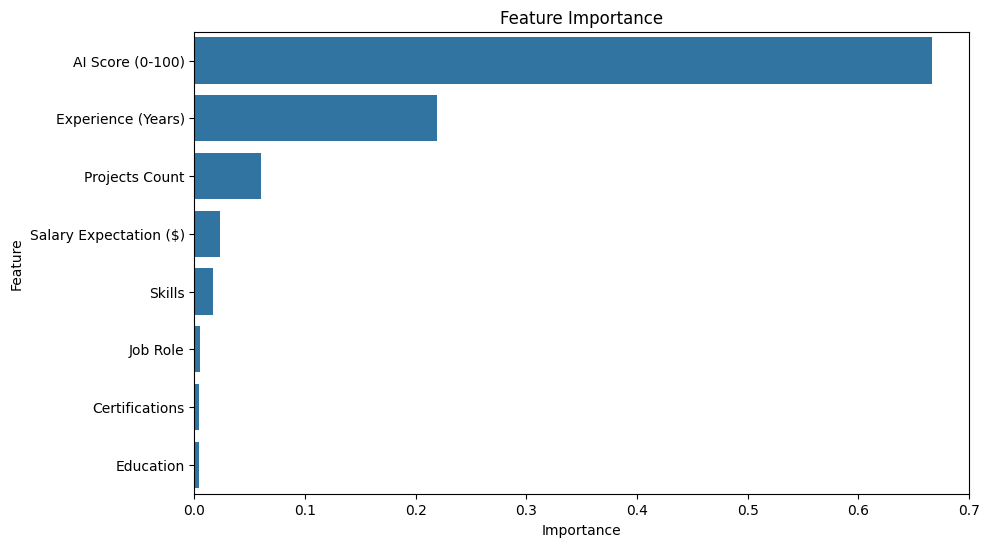

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()


In [ ]:
import joblib


joblib.dump(best_model, "random_forest_model.pkl")

joblib.dump(scalar, "scaler.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
df.head(10)

,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,226,10,0,3,0,0,104895,8,100
1,32,10,3,2,2,0,113002,1,100
2,46,1,3,1,1,0,71766,7,70
3,152,7,1,0,0,0,46848,0,95
4,221,4,4,3,3,0,87441,9,100
5,29,10,1,2,1,0,47957,5,100
6,120,4,2,0,1,0,66208,9,100
7,234,3,2,0,0,0,103006,7,90
8,124,7,3,1,1,0,92270,3,100
9,163,0,2,0,0,1,60579,1,35


In [ ]:
new_candidate = [[32, 10, 3, 2, 2, 113002, 1, 100]]

new_candidate_scaled = scalar.transform(new_candidate)

prediction = best_model.predict(new_candidate_scaled)
if prediction[0] == 0:
    print("Prediction: Hire")
else:
    print("Prediction: Reject")

Prediction: Reject


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
print(en.inverse_transform(prediction))

[1]


In [ ]:
candidate = x.iloc[[1]]   # Row 1

candidate_scaled = scalar.transform(candidate)

prediction = best_model.predict(candidate_scaled)

print("Actual:", en.inverse_transform([y.iloc[1]])[0])
print("Predicted:", en.inverse_transform(prediction)[0])

Actual: 0
Predicted: 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
print(results_df)

                 Model  Accuracy  Recall  F1 Score
0        Decision Tree       1.0     1.0       1.0
1  Logistic Regression       1.0     1.0       1.0
2        Random Forest       1.0     1.0       1.0
